# DocuDevs: Convert a Complex PDF Form to AcroForm

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/docudevs/python-examples/blob/main/08-pdf-acroform-metadata.ipynb)
[![GitHub](https://img.shields.io/badge/GitHub-View_Source-blue?logo=github)](https://github.com/docudevs/python-examples)

This notebook uses the public `docs/medical-examination-form.pdf` sample. The PDF is a complex multi-page form, but it does not contain native AcroForm fields.

The workflow is:

1. Confirm the original PDF has no AcroForm fields.
2. Process the PDF with premium OCR so page images are available.
3. Run the `pdf-acroform` operation with visual field detection.
4. Download the generated fillable PDF.
5. Inspect AcroForm metadata and normalized field definitions.
6. Render field definitions on page images for human review.


In [ ]:
# Install dependencies (required in Colab)
# Colab includes packages such as gradio and google-genai with their own
# pydantic/httpx constraints. Install compatible shared deps first, then
# install the SDK without letting older SDK metadata downgrade them.
%pip install -q --upgrade "pydantic>=2.0,<=2.12.3" "httpx>=0.28.1,<1.0" "attrs>=21.3.0" "python-dateutil>=2.8.0" "click>=8.0.0" "matplotlib" "pillow"
%pip install -q --upgrade --no-deps docu-devs-api-client


## Setup

These examples use the published `docu-devs-api-client` package from PyPI. For Colab, store `DOCUDEVS_API_KEY` in the 🔑 Secrets sidebar. You can also set it as an environment variable before running the notebook.


In [ ]:
import asyncio
import importlib.metadata
import io
import json
import os
import time
import urllib.request
from http import HTTPStatus
from pathlib import Path
from typing import Any, Optional

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

from docudevs import DocuDevsClient

# Set your API key:
# Option 1: Colab Secrets (recommended) — add DOCUDEVS_API_KEY in the 🔑 sidebar
# Option 2: Environment variable
# Option 3: Set directly below
try:
    from google.colab import userdata
    API_KEY = userdata.get("DOCUDEVS_API_KEY")
except Exception:
    API_KEY = os.getenv("DOCUDEVS_API_KEY", "your-api-key-here")

if not API_KEY or API_KEY == "your-api-key-here":
    raise ValueError("Set your DOCUDEVS_API_KEY - get one at https://docudevs.ai")

client = DocuDevsClient(token=API_KEY)
Path("outputs/acroforms").mkdir(parents=True, exist_ok=True)
print(f"Connected to DocuDevs API with SDK {importlib.metadata.version('docu-devs-api-client')}")


Connected to DocuDevs API with SDK 1.10.2


## Load the Medical Examination Form


In [2]:
docs_dir = Path("docs")
docs_dir.mkdir(exist_ok=True)

pdf_path = docs_dir / "medical-examination-form.pdf"
pdf_url = (
    "https://raw.githubusercontent.com/docudevs/python-examples/main/docs/"
    "medical-examination-form.pdf"
)

if not pdf_path.exists():
    urllib.request.urlretrieve(pdf_url, str(pdf_path))

if not pdf_path.exists():
    raise FileNotFoundError(f"Missing {pdf_path}")

pdf_bytes = pdf_path.read_bytes()
print(f"Loaded {pdf_path.name}: {len(pdf_bytes):,} bytes")


Loaded medical-examination-form.pdf: 2,534,097 bytes


## Confirm the Original PDF Has No AcroForm Fields


In [3]:
original_metadata = await client.extract_acroform_metadata(
    document=pdf_bytes,
    file_name=pdf_path.name,
    mime_type="application/pdf",
)

print(f"Pages: {len(original_metadata.get('pages', []))}")
print(f"Original AcroForm fields: {len(original_metadata.get('fields', []))}")
print(json.dumps(original_metadata.get("fields", [])[:5], indent=2, ensure_ascii=False))


Pages: 5
Original AcroForm fields: 0
[]


## Shared Helpers


In [4]:
def to_plain(value: Any) -> Any:
    if hasattr(value, "to_dict"):
        return to_plain(value.to_dict())
    if hasattr(value, "model_dump"):
        return to_plain(value.model_dump())
    if isinstance(value, list):
        return [to_plain(item) for item in value]
    if isinstance(value, dict):
        return {key: to_plain(item) for key, item in value.items()}
    if hasattr(value, "__dict__") and value.__class__.__module__ != "builtins":
        return {key: to_plain(item) for key, item in vars(value).items()}
    return value


def operation_result_payload(result: Any) -> Any:
    plain = to_plain(result)
    if isinstance(plain, dict) and "result" in plain:
        raw_result = plain["result"]
        if isinstance(raw_result, str):
            try:
                return json.loads(raw_result)
            except Exception:
                return raw_result
        return raw_result
    if isinstance(plain, str):
        try:
            return json.loads(plain)
        except Exception:
            return plain
    return plain


def require_metadata(metadata: Optional[dict[str, Any]], artifact_name: str) -> dict[str, Any]:
    if metadata is None:
        raise RuntimeError(f"{artifact_name} was not available")
    return metadata


async def process_pdf_for_acroform_parent(pdf_file: Path) -> str:
    parent_job_id = await client.submit_and_process_document(
        document=pdf_file.read_bytes(),
        document_mime_type="application/pdf",
        ocr="PREMIUM",
        extraction_mode="OCR",
        acro_form_metadata=True,
    )
    await client.wait_until_ready(parent_job_id, timeout=900, poll_interval=5)
    return parent_job_id


## Process the PDF and Convert It to a Fillable AcroForm PDF

`llm_type="DEFAULT"` keeps the language-model tier at the default level. `ocr="PREMIUM"` ensures page images are generated for field detection and later visual review.


In [9]:
# If you want to override the defaults of 0.6 and 200
# ACROFORM_MIN_CONFIDENCE = 0.35
# MAX_FIELDS_PER_PAGE = 300

print(f"Submitting parent OCR job for {pdf_path.name}...")
parent_job_id = await process_pdf_for_acroform_parent(pdf_path)
print(f"Parent job completed: {parent_job_id}")

output_path = Path("outputs/acroforms") / f"{pdf_path.stem}-fillable.pdf"

print("Running pdf-acroform operation...")
conversion = await client.submit_and_wait_for_pdf_acroform_operation(
    parent_job_id,
    llm_type="DEFAULT",
    ocr="PREMIUM",
    # min_confidence=ACROFORM_MIN_CONFIDENCE,
    # max_fields_per_page=MAX_FIELDS_PER_PAGE,
    timeout=1200,
    poll_interval=10,
    save_to=str(output_path),
)

manifest = operation_result_payload(conversion.result)
print(f"Operation job: {conversion.operation_job_guid}")
print(f"Generated PDF saved to {output_path}")
if isinstance(manifest, dict):
    print(f"Written fields: {manifest.get('writtenFieldCount')}")
    print(f"Skipped fields: {len(manifest.get('skippedFields', []))}")
print(json.dumps(manifest, indent=2, ensure_ascii=False)[:4000])


Submitting parent OCR job for medical-examination-form.pdf...
Parent job completed: 4cd7e9e1-efd1-4f7f-bb2d-f2df4445b245
Running pdf-acroform operation...
Operation job: 8747f539-5594-4e56-be1a-a7d546b18407
Generated PDF saved to outputs/acroforms/medical-examination-form-fillable.pdf
Written fields: 324
Skipped fields: 0
{
  "version": 1,
  "operationType": "pdf-acroform",
  "parentJobGuid": "4cd7e9e1-efd1-4f7f-bb2d-f2df4445b245",
  "generatedPdfPath": "operations/8747f539-5594-4e56-be1a-a7d546b18407/result.pdf",
  "fieldCount": 324,
  "writtenFieldCount": 324,
  "skippedFieldCount": 0,
  "warnings": [
    "Field names are derived in snake_case from visible English labels because the source page is in English.",
    "Choice controls in the No/Yes columns were interpreted as radio buttons based on repeated mutually exclusive layout; substance-type options under question 02 were interpreted as checkboxes.",
    "Field names use source-language-style snake_case with Finnish-style identif

## Fetch Generated AcroForm Metadata and Field Definitions

AcroForm metadata describes the fields that exist in the generated PDF. Field definitions are the normalized detection artifact that can be reviewed and edited before applying changes back to the plain PDF.


In [10]:
generated_metadata = await client.get_acroform_metadata(conversion.operation_job_guid)
if generated_metadata is None:
    generated_metadata = await client.extract_acroform_metadata(
        document=conversion.pdf,
        file_name=output_path.name,
        mime_type="application/pdf",
    )

field_definitions_artifact = await client.get_pdf_acroform_field_definitions(
    conversion.operation_job_guid
)
field_definitions_artifact = require_metadata(
    field_definitions_artifact,
    "pdf-acroform field definitions",
)
field_definitions = field_definitions_artifact.get("fieldDefinitions", [])

print(f"Generated metadata fields: {len(generated_metadata.get('fields', []))}")
print(f"Field definitions: {len(field_definitions)}")

print()
print("First generated metadata fields:")
print(json.dumps(generated_metadata.get("fields", [])[:5], indent=2, ensure_ascii=False))

print()
print("First normalized field definitions:")
print(json.dumps(field_definitions[:5], indent=2, ensure_ascii=False))


Generated metadata fields: 324
Field definitions: 324

First generated metadata fields:
[
  {
    "id": "/acroform/fields/0",
    "name": "applicants_personal_details_address",
    "partialName": "applicants_personal_details_address",
    "type": "text",
    "tooltip": "Address",
    "mappingName": null,
    "value": "",
    "defaultValue": null,
    "flags": [],
    "options": [],
    "widgets": [
      {
        "id": "/acroform/widgets/6",
        "fieldRef": "/acroform/fields/0",
        "pageNumber": 1,
        "rect": [
          26.18,
          495.066,
          240.38,
          511.368
        ],
        "appearanceState": null,
        "pageAnchors": [
          {
            "pageNumber": 1,
            "unit": "point",
            "bbox": {
              "left": 26.18,
              "top": 346.632,
              "right": 240.38,
              "bottom": 362.934
            },
            "polygons": [
              [
                {
                  "x": 26.18,
        

## Render Normalized Field Definitions on Page Images

These boxes use normalized page-image coordinates. This is the most useful artifact for a human-in-the-loop editor because the same data can be posted back to the `pdf-acroform/apply` endpoint after edits.


Pages with detected fields: [1, 2, 3, 4, 5]


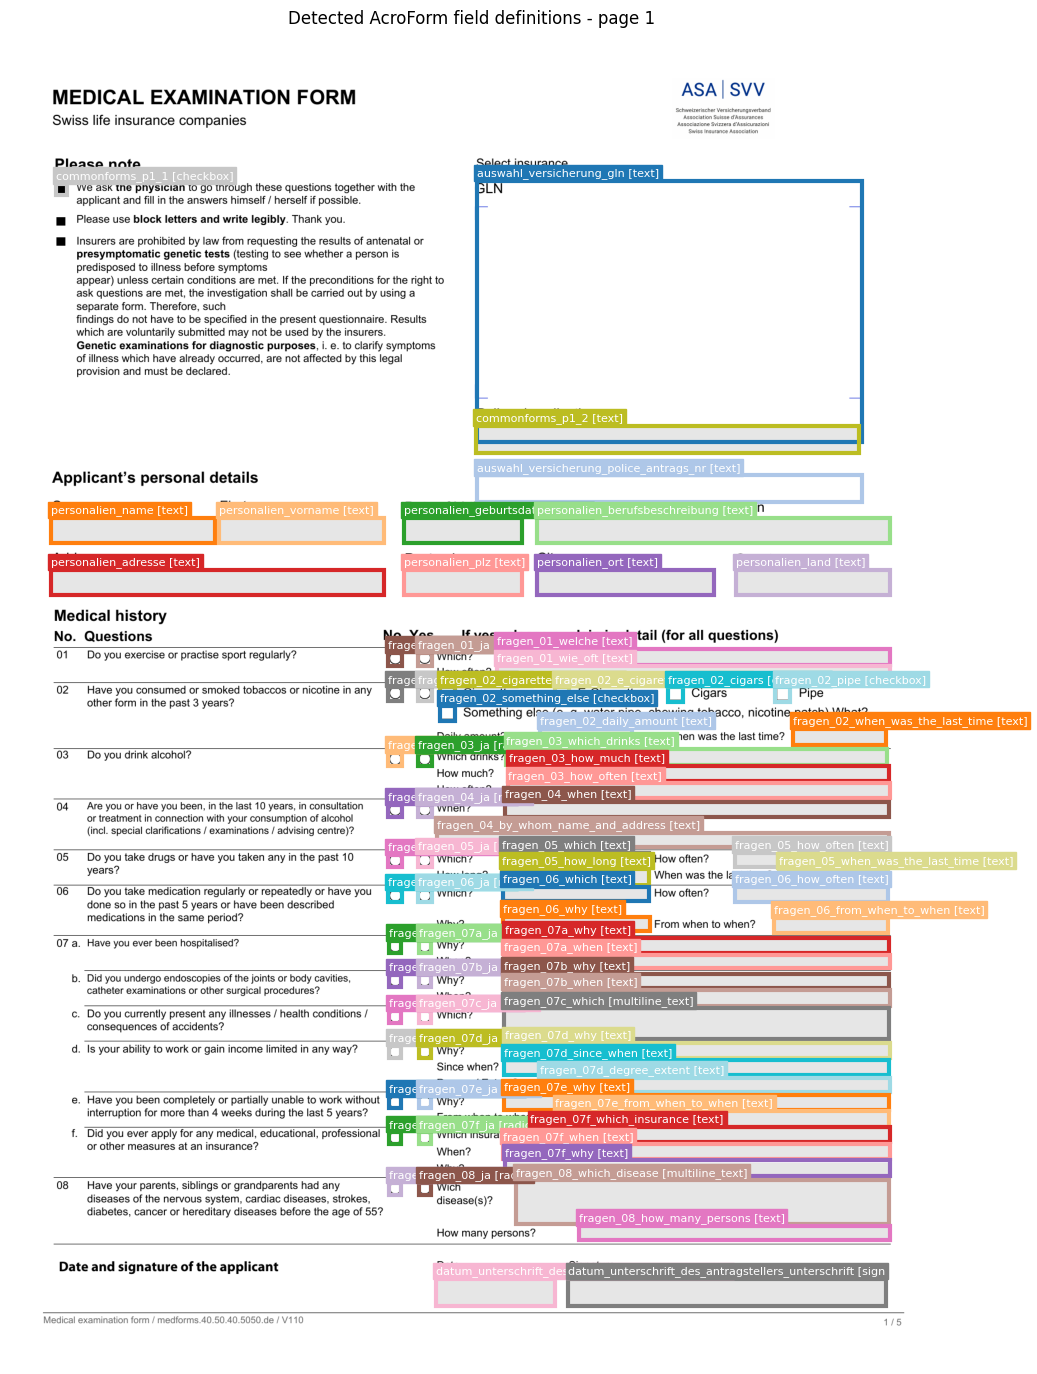

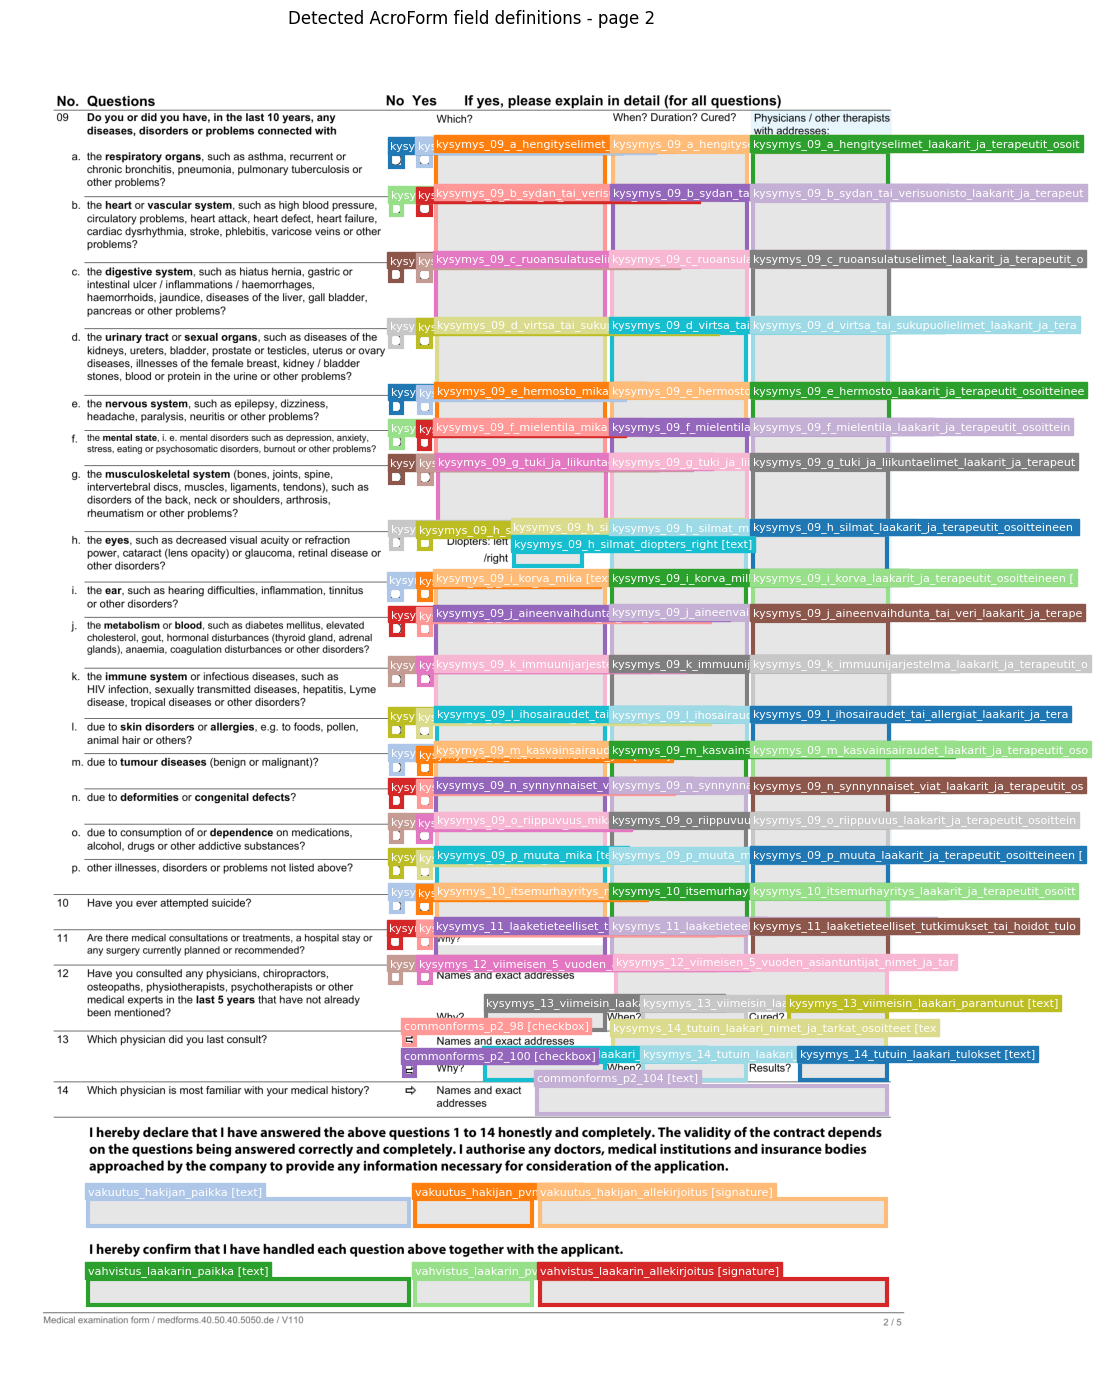

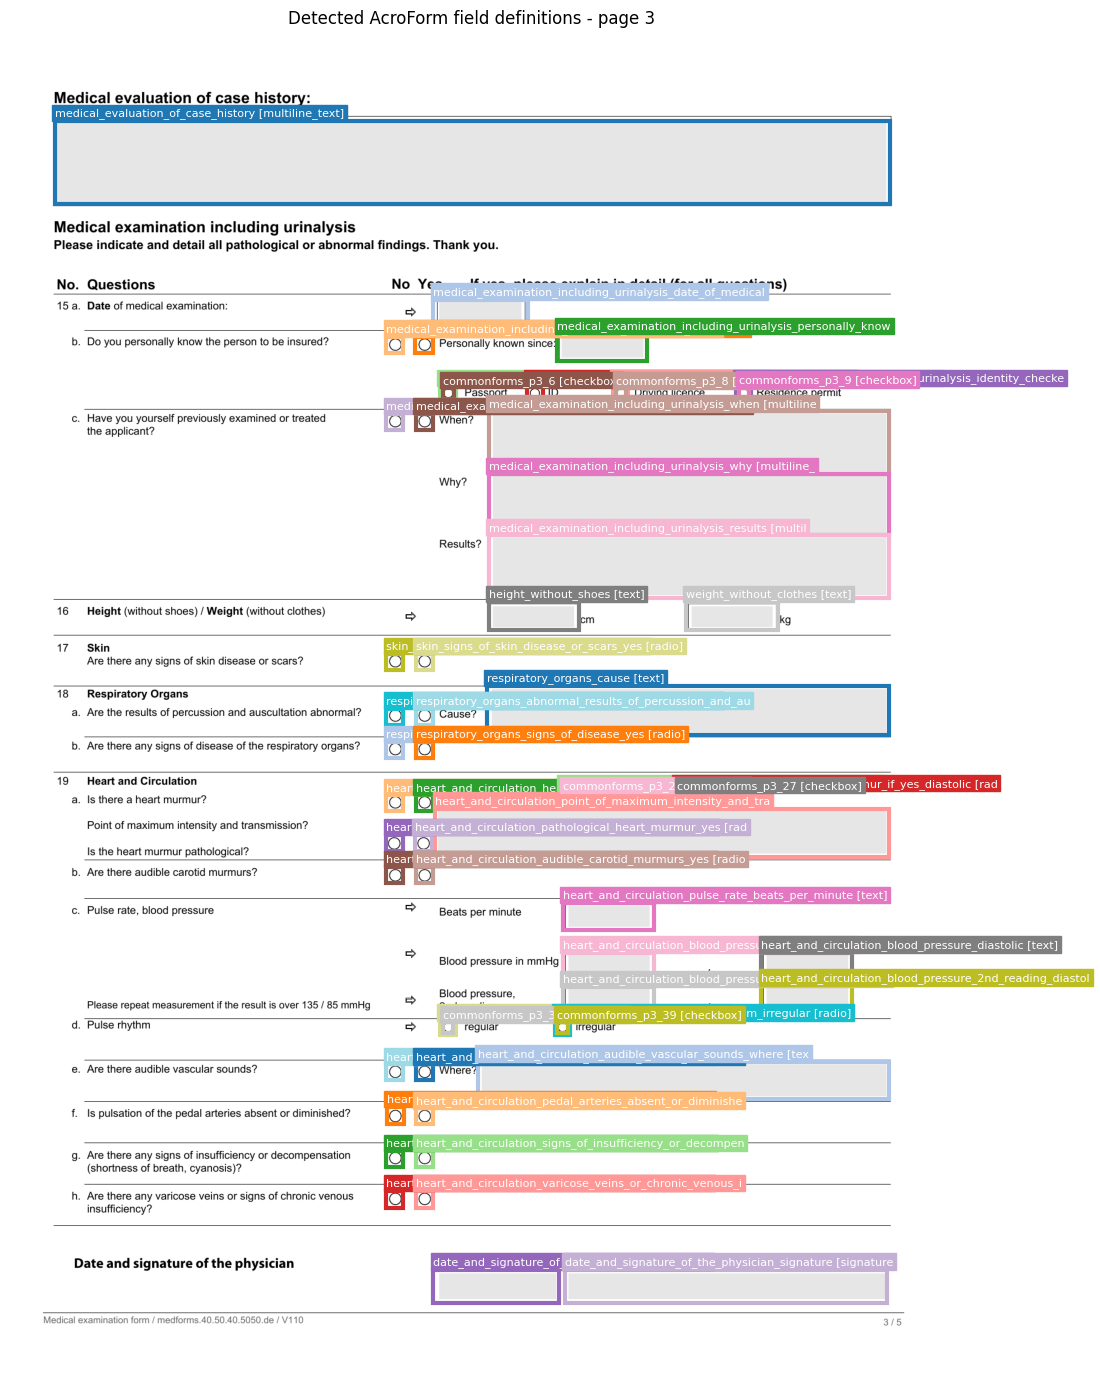

In [11]:
def definition_bbox(field: dict[str, Any]) -> dict[str, float]:
    bbox = field.get("entryBbox") or field.get("entry_bbox") or {}
    return {
        "left": float(bbox["left"]),
        "top": float(bbox["top"]),
        "right": float(bbox["right"]),
        "bottom": float(bbox["bottom"]),
    }


async def load_parent_page_image(parent_job_guid: str, page_number: int) -> Image.Image:
    image_bytes = await client.get_image(parent_job_guid, page_index=page_number - 1)
    if not image_bytes:
        raise RuntimeError(
            f"Parent job {parent_job_guid} has no rendered image for page {page_number}. "
            "Run the parent job with premium OCR before drawing field definitions."
        )
    return Image.open(io.BytesIO(image_bytes)).convert("RGB")


async def render_field_definitions(
    parent_job_guid: str,
    artifact: dict[str, Any],
    *,
    page_number: int,
    title: str = "Detected AcroForm field definitions",
) -> None:
    image = await load_parent_page_image(parent_job_guid, page_number)
    page_fields = [
        field
        for field in artifact.get("fieldDefinitions", [])
        if int(field.get("pageNumber", 0)) == page_number
    ]
    if not page_fields:
        raise ValueError(f"No field definitions found on page {page_number}")

    colors = plt.cm.tab20.colors
    fig, ax = plt.subplots(figsize=(12, 12 * image.height / image.width))
    ax.imshow(image)

    for index, field in enumerate(page_fields):
        bbox = definition_bbox(field)
        left = bbox["left"] * image.width
        top = bbox["top"] * image.height
        width = (bbox["right"] - bbox["left"]) * image.width
        height = (bbox["bottom"] - bbox["top"]) * image.height
        color = colors[index % len(colors)]
        ax.add_patch(Rectangle((left, top), width, height, fill=False, linewidth=3, edgecolor=color))
        label = field.get("fieldName") or field.get("label") or f"field_{index + 1}"
        field_type = field.get("fieldType") or field.get("field_type") or "field"
        ax.text(
            left,
            max(top - 10, 12),
            f"{label} [{field_type}]"[:56],
            color="white",
            fontsize=8,
            bbox={"facecolor": color, "edgecolor": color, "pad": 2},
        )

    ax.set_title(f"{title} - page {page_number}")
    ax.axis("off")
    plt.show()


field_definition_pages = sorted(
    {
        int(field.get("pageNumber"))
        for field in field_definitions_artifact.get("fieldDefinitions", [])
        if field.get("pageNumber")
    }
)

print(f"Pages with detected fields: {field_definition_pages}")
for page_number in field_definition_pages[:3]:
    await render_field_definitions(
        parent_job_id,
        field_definitions_artifact,
        page_number=page_number,
    )


## Render Generated AcroForm Widgets from PDF Metadata

This view comes from the generated PDF itself. Widget coordinates are PDF points, scaled onto the parent job thumbnails for inspection.


Pages with generated widgets: [1, 2, 3, 4, 5]


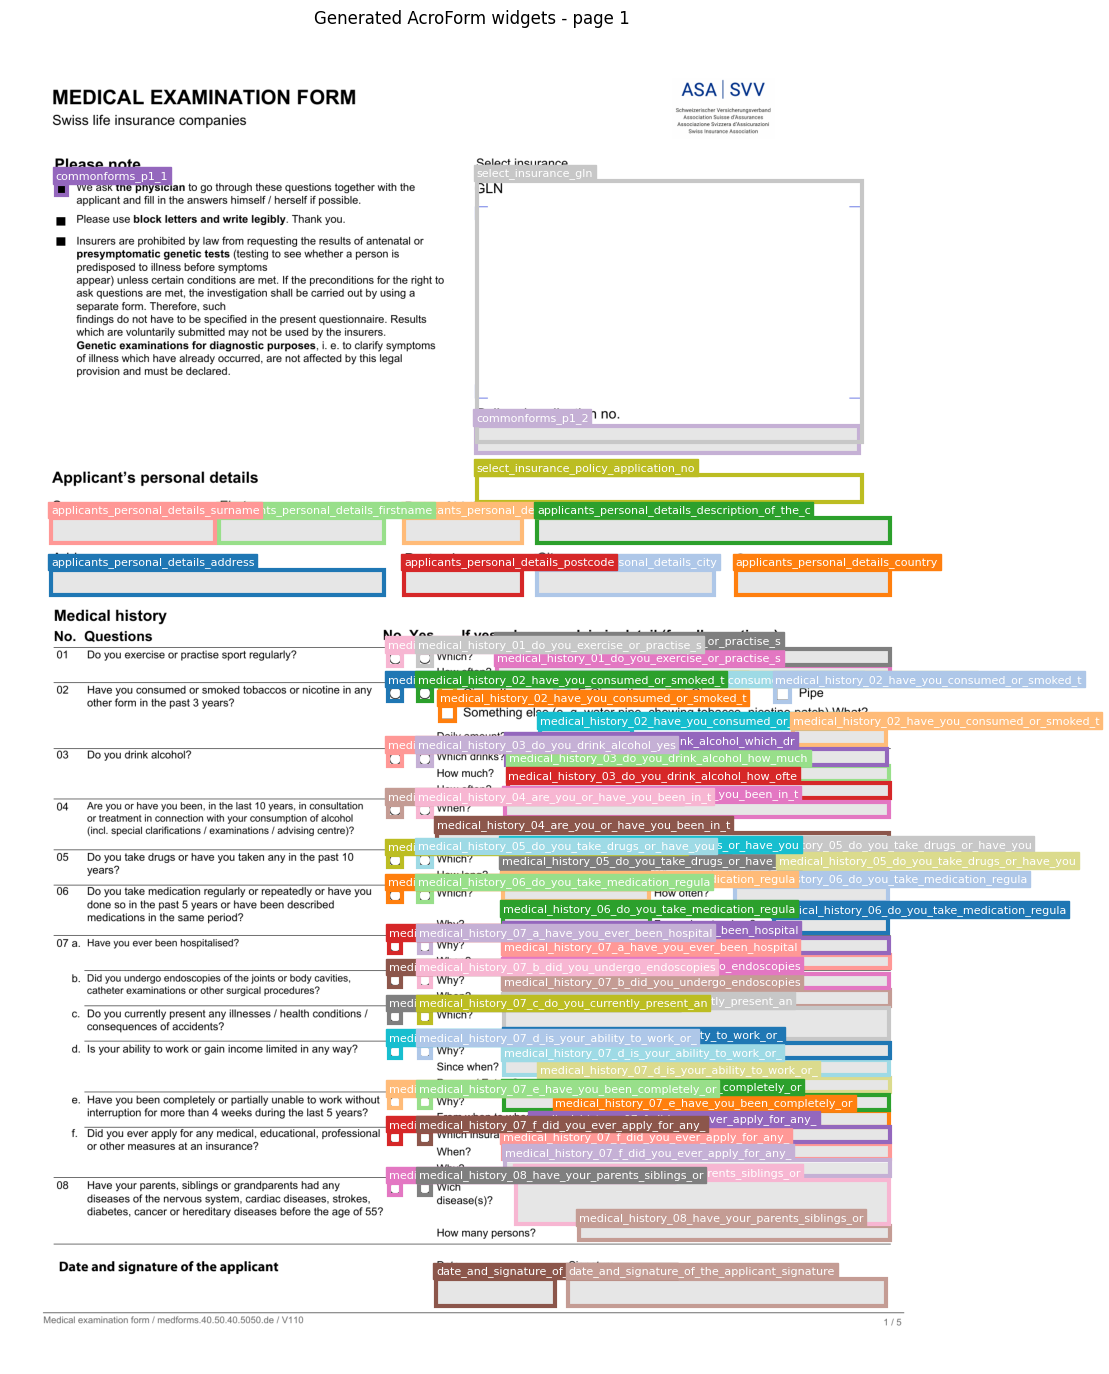

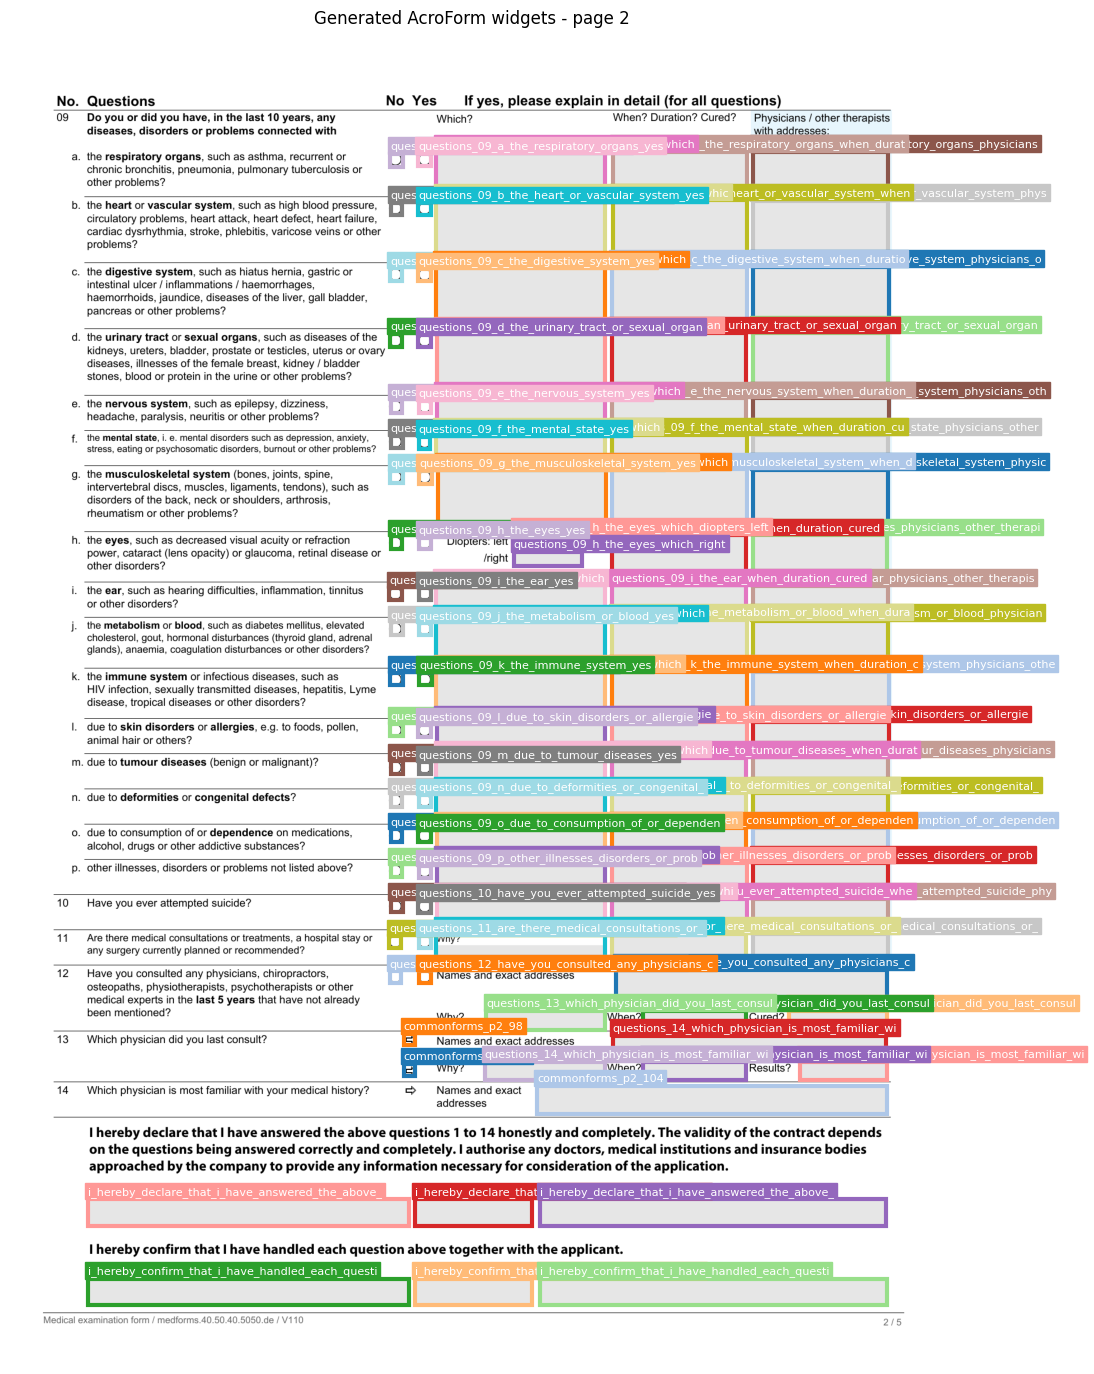

In [12]:
def page_info(metadata: dict[str, Any], page_number: int) -> dict[str, Any]:
    for page in metadata.get("pages", []):
        if int(page.get("pageNumber", 0)) == page_number:
            return page
    raise ValueError(f"Missing page {page_number} metadata")


def widgets_on_page(metadata: dict[str, Any], page_number: int) -> list[tuple[dict[str, Any], dict[str, Any]]]:
    widgets = []
    for field in metadata.get("fields", []):
        for widget in field.get("widgets", []):
            if int(widget.get("pageNumber", 0)) == page_number:
                widgets.append((field, widget))
    return widgets


async def render_acroform_metadata_widgets(
    parent_job_guid: str,
    metadata: dict[str, Any],
    *,
    page_number: int,
) -> None:
    image = await load_parent_page_image(parent_job_guid, page_number)
    page = page_info(metadata, page_number)
    scale_x = image.width / float(page["width"])
    scale_y = image.height / float(page["height"])
    page_widgets = widgets_on_page(metadata, page_number)
    if not page_widgets:
        raise ValueError(f"No generated AcroForm widgets found on page {page_number}")

    colors = plt.cm.tab20.colors
    fig, ax = plt.subplots(figsize=(12, 12 * image.height / image.width))
    ax.imshow(image)

    for index, (field, widget) in enumerate(page_widgets):
        anchors = widget.get("pageAnchors", [])
        if not anchors:
            continue
        bbox = anchors[0]["bbox"]
        left = bbox["left"] * scale_x
        top = bbox["top"] * scale_y
        width = (bbox["right"] - bbox["left"]) * scale_x
        height = (bbox["bottom"] - bbox["top"]) * scale_y
        color = colors[index % len(colors)]
        ax.add_patch(Rectangle((left, top), width, height, fill=False, linewidth=3, edgecolor=color))
        label = field.get("name", widget.get("id", "field"))
        ax.text(
            left,
            max(top - 10, 12),
            str(label)[:48],
            color="white",
            fontsize=8,
            bbox={"facecolor": color, "edgecolor": color, "pad": 2},
        )

    ax.set_title(f"Generated AcroForm widgets - page {page_number}")
    ax.axis("off")
    plt.show()


widget_pages = sorted(
    {
        int(widget.get("pageNumber"))
        for field in generated_metadata.get("fields", [])
        for widget in field.get("widgets", [])
        if widget.get("pageNumber")
    }
)

print(f"Pages with generated widgets: {widget_pages}")
for page_number in widget_pages[:2]:
    await render_acroform_metadata_widgets(
        parent_job_id,
        generated_metadata,
        page_number=page_number,
    )


## Optional: Apply Reviewed Field Definitions

A human review UI can edit the normalized field definitions and post the edited list back to the apply endpoint. The cell below is disabled by default because it creates a second generated PDF. Set `RUN_APPLY_EXAMPLE = True` after making any edits you want to test.


In [ ]:
RUN_APPLY_EXAMPLE = False

reviewed_field_definitions = json.loads(json.dumps(field_definitions))
for field in reviewed_field_definitions:
    field.setdefault("reviewStatus", "accepted")

if RUN_APPLY_EXAMPLE:
    applied_output_path = Path("outputs/acroforms") / f"{pdf_path.stem}-reviewed-fillable.pdf"
    apply_result = await client.submit_and_wait_for_pdf_acroform_apply_operation(
        parent_job_id,
        field_definitions=reviewed_field_definitions,
        source_operation_guid=conversion.operation_job_guid,
        min_confidence=0.0,
        max_fields_per_page=MAX_FIELDS_PER_PAGE,
        timeout=1200,
        poll_interval=10,
        save_to=str(applied_output_path),
    )
    applied_manifest = operation_result_payload(apply_result.result)
    applied_metadata = await client.get_acroform_metadata(apply_result.operation_job_guid)
    print(f"Apply operation: {apply_result.operation_job_guid}")
    print(f"Reviewed PDF saved to {applied_output_path}")
    print(f"Written fields: {applied_manifest.get('writtenFieldCount') if isinstance(applied_manifest, dict) else 'unknown'}")
    print(f"Metadata fields: {len((applied_metadata or {}).get('fields', []))}")
else:
    print(
        "Edit reviewed_field_definitions, then set RUN_APPLY_EXAMPLE = True "
        "to regenerate the PDF from reviewed fields."
    )
